In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage
from skimage.morphology import disk, ball
import cupy as cp
import cupyx.scipy.ndimage as GPUndimage
from cucim.skimage.morphology import ball as GPUball
import xarray as xr

# Analyse ACL trace

## load example images from TOMCAT and labCT campaigns

In [32]:
path_tom_0 = '/mnt/SSD/fische_r/COELY/3II_lowpass_ts_4.tif'
path_tom_1 = '/mnt/SSD/fische_r/COELY/3II_lowpass_ts_40.tif'

path_CT_0 = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_12/A_12_preop_rotcrop.tif'
path_CT_1 = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_12/A_12_postop_2_rotcrop.tif'

tom_slice = 289
ct_slice = 283


In [33]:
im_tom_0 = skimage.io.imread(path_tom_0)[tom_slice, ...]
im_tom_1 = skimage.io.imread(path_tom_1)[tom_slice, ...]

In [34]:
im_ct_0 = np.transpose(skimage.io.imread(path_CT_0)[:,ct_slice,:], (1,0))
im_ct_1 = np.transpose(skimage.io.imread(path_CT_1)[:,ct_slice,:], (1,0))

## extract CCL spine

In [35]:
def pad_and_close(im, radius):
    shp = np.array(im.shape)+2*radius
    im_padded = np.zeros(shp, dtype=bool)
    im_padded[radius:-radius,radius:-radius] = im
    im_padded = skimage.morphology.binary_closing(im_padded, disk(radius))
    im = im_padded[radius:-radius,radius:-radius]
    return im

def pad_and_close3D(im, radius):
    shp = np.array(im.shape)+2*radius
    im_padded = np.zeros(shp, dtype=bool)
    im_padded[radius:-radius,radius:-radius,radius:-radius] = im
    
    # im_padded = skimage.morphology.binary_closing(im_padded, ball(radius))
    # use gpu for speed up
    imgpu = cp.array(im_padded)
    imgpu =  GPUndimage.binary_closing(imgpu, structure=GPUball(radius))
    im_padded = cp.asnumpy(imgpu)

    del imgpu
    mempool = cp.get_default_memory_pool()
    mempool.free_all_blocks()
    
    im = im_padded[radius:-radius,radius:-radius,radius:-radius]
    return im

### tomcat 0

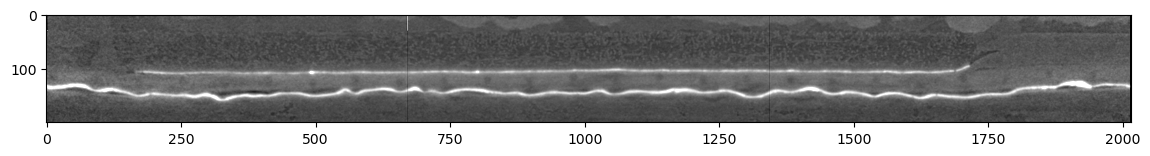

In [38]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_0[200:400,...], 'gray', vmin=7771, vmax=20529)

In [39]:
im_tom_0_seg = im_tom_0>15000
im_tom_0_seg[:320,:] = False
im_tom_0_seg = pad_and_close(im_tom_0_seg, 30)

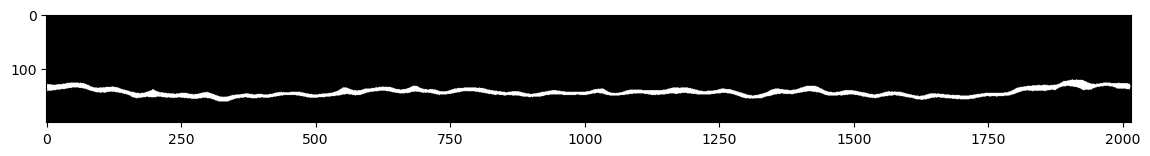

In [40]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_0_seg[200:400,...], 'gray')

### tomcat 1

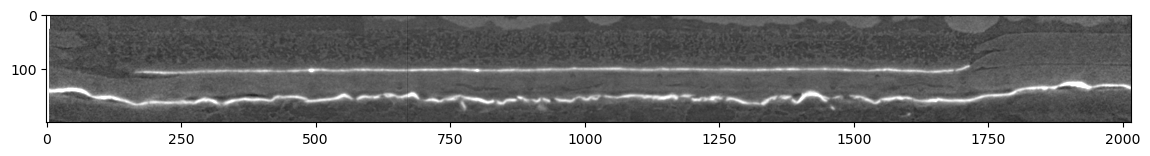

In [41]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_1[ 200:400,...], 'gray', vmin=7771, vmax=20529)

In [42]:
im_tom_1_seg = im_tom_1>15000
im_tom_1_seg[:320,:] = False
im_tom_1_seg = pad_and_close(im_tom_1_seg, 30)

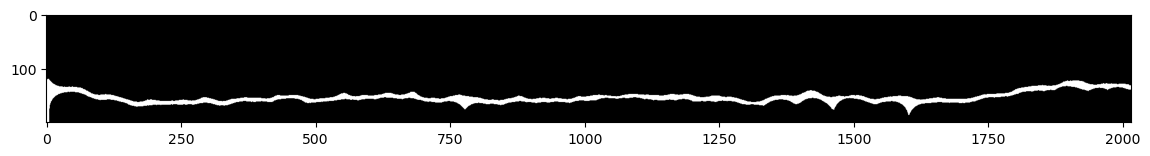

In [43]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_1_seg[200:400,...], 'gray')

### labCT 0

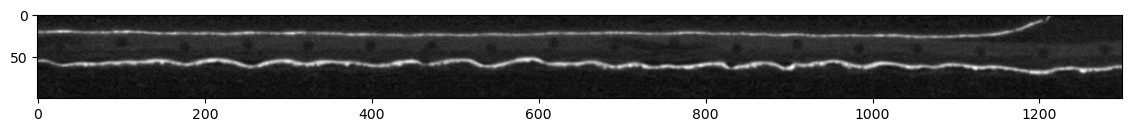

In [44]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_0, 'gray')

In [45]:
im_ct_0_seg = im_ct_0>0.35
im_ct_0_seg[:30,:] = False
im_ct_0_seg = pad_and_close(im_ct_0_seg, 30)

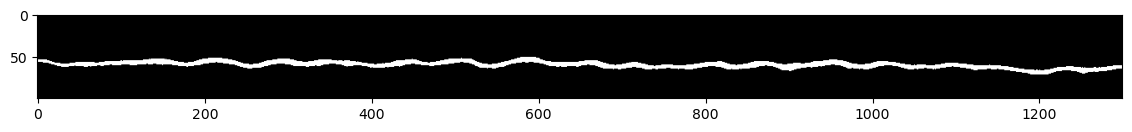

In [46]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_0_seg, 'gray')

### labCT 1

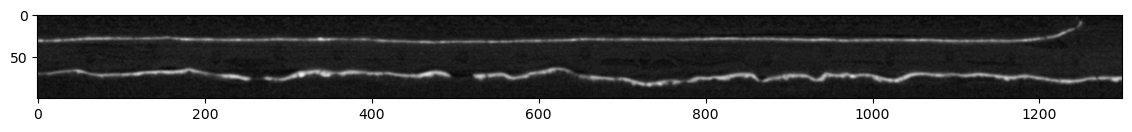

In [47]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_1, 'gray')

In [71]:
im_ct_1_seg = im_ct_1>0.35
im_ct_1_seg[:40,:] = False
im_ct_1_seg = pad_and_close(im_ct_1_seg, 35)

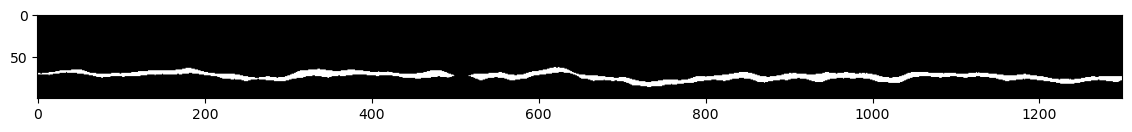

In [72]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_1_seg, 'gray')

## plot ACL profiles

In [73]:
im_tom_0_ACL = im_tom_0*im_tom_0_seg*1.0
im_tom_0_ACL[im_tom_0_ACL==0] = np.nan

im_tom_1_ACL = im_tom_1*im_tom_1_seg*1.0
im_tom_1_ACL[im_tom_1_ACL==0] = np.nan

(0.5, 1.0)

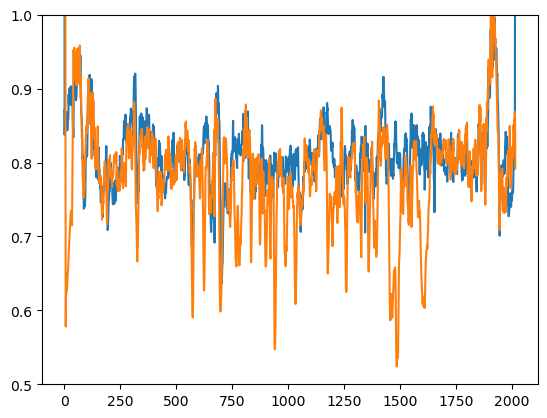

In [74]:
plt.plot(np.nanmean(im_tom_0_ACL/22000,axis=0))
plt.plot(np.nanmean(im_tom_1_ACL/22000,axis=0))
plt.ylim(0.5,1)

In [75]:
hist_tom_0 = np.histogram(np.nanmedian(im_tom_0_ACL, axis=0), bins = np.arange(0,1,0.025)*23000)
hist_tom_1 = np.histogram(np.nanmedian(im_tom_1_ACL, axis=0), bins = np.arange(0,1,0.025)*23000)

Text(0, 0.5, 'counts')

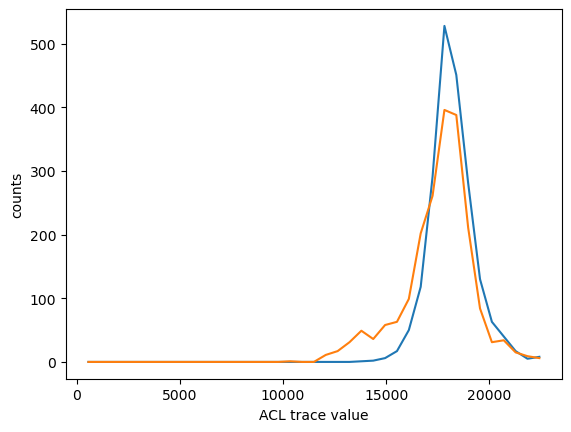

In [76]:
plt.plot(hist_tom_0[1][1:], hist_tom_0[0])
plt.plot(hist_tom_1[1][1:], hist_tom_1[0])
plt.xlabel('ACL trace value')
plt.ylabel('counts')

In [77]:
im_ct_0_ACL = im_ct_0*im_ct_0_seg*1.0
im_ct_0_ACL[im_ct_0_ACL==0] = np.nan

im_ct_1_ACL = im_ct_1*im_ct_1_seg*1.0
im_ct_1_ACL[im_ct_1_ACL==0] = np.nan

/tmp/ipykernel_427497/2187332592.py:2: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(im_ct_1_ACL/0.85,axis=0))


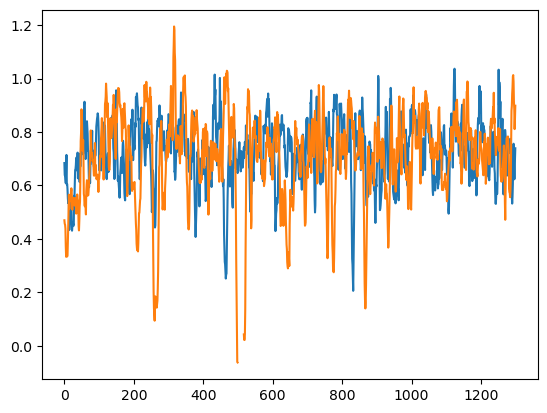

In [78]:
plt.plot(np.nanmean(im_ct_0_ACL/0.85,axis=0))
plt.plot(np.nanmean(im_ct_1_ACL/0.85,axis=0))
# plt.ylim(10000,25000)

In [79]:
hist_ct_0 = np.histogram(np.nanmedian(im_ct_0_ACL, axis=0), bins = np.arange(0,1,0.025))
hist_ct_1 = np.histogram(np.nanmedian(im_ct_1_ACL, axis=0), bins = np.arange(0,1,0.025))

/tmp/ipykernel_427497/647194438.py:2: RuntimeWarning: All-NaN slice encountered
  hist_ct_1 = np.histogram(np.nanmedian(im_ct_1_ACL, axis=0), bins = np.arange(0,1,0.025))


Text(0, 0.5, 'counts')

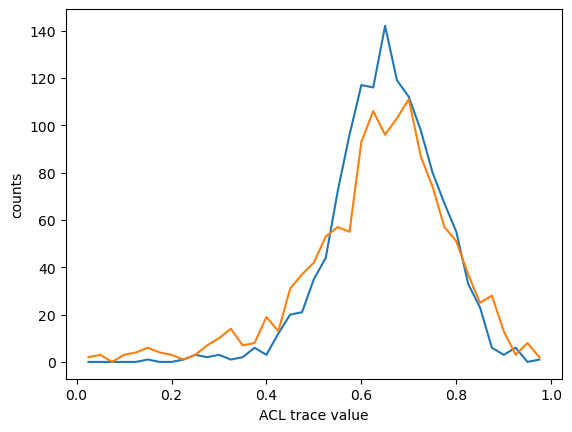

In [80]:
plt.plot(hist_ct_0[1][1:], hist_ct_0[0])
plt.plot(hist_ct_1[1][1:], hist_ct_1[0])
plt.xlabel('ACL trace value')
plt.ylabel('counts')

# same analysis in 3D

In [116]:
im_tom_0 = skimage.io.imread(path_tom_0) # ts 4
im_tom_1 = skimage.io.imread(path_tom_1) # ts 40

In [5]:
seg_data = xr.open_dataset('/mnt/nas_nanotomData/CT_Data_PSI/FR54/misc/06_3II_anode_CL_segmented_filtered.nc')

## tomcat 0

In [114]:
im_tom_0_seg = seg_data['segmented'][...,4].data

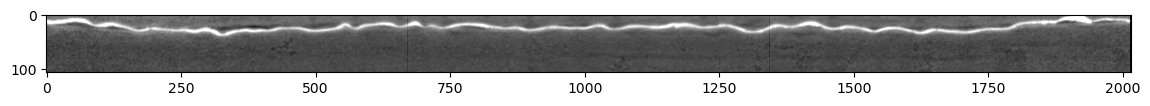

In [7]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_0[tom_slice,321:427,:], 'gray', vmin=7771, vmax=20529)

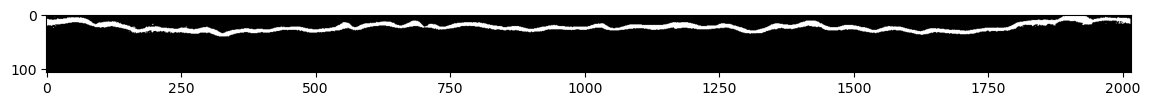

In [8]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_0_seg[tom_slice,:,:], 'gray')

In [9]:
im_tom_0_trace = pad_and_close3D(im_tom_0_seg, 30)

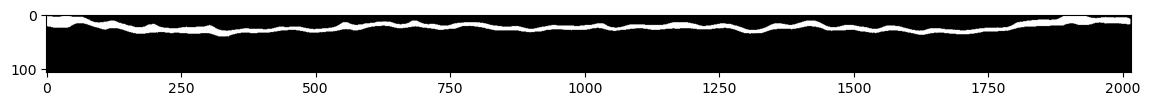

In [10]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_0_trace[tom_slice,:,:], 'gray')

In [117]:
im_tom_0_ACL = im_tom_0[:,321:427,:]*1.0
im_tom_0_ACL[~im_tom_0_trace] = np.nan

## tomcat 1

In [16]:
im_tom_1_seg = seg_data['segmented'][...,40].data

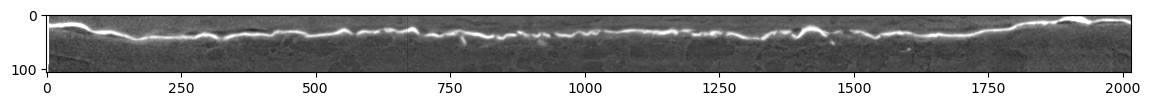

In [17]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_1[tom_slice,321:427,:], 'gray', vmin=7771, vmax=20529)

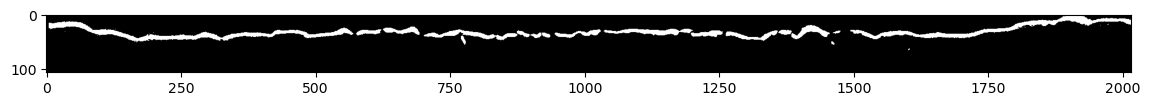

In [18]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_1_seg[tom_slice,:,:], 'gray')

In [19]:
im_tom_1_trace = pad_and_close3D(im_tom_1_seg, 30)

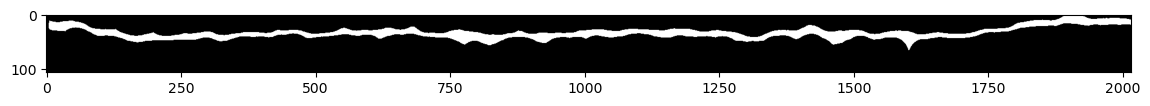

In [20]:
plt.figure(figsize=(14,7))
plt.imshow(im_tom_1_trace[tom_slice,:,:], 'gray')

In [118]:
im_tom_1_ACL = im_tom_1[:,321:427,:]*1.0
im_tom_1_ACL[~im_tom_1_trace] = np.nan

/tmp/ipykernel_427497/1505749467.py:2: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(im_tom_0_ACL, axis=1), 'gray')
/tmp/ipykernel_427497/1505749467.py:5: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(im_tom_1_ACL, axis=1), 'gray')


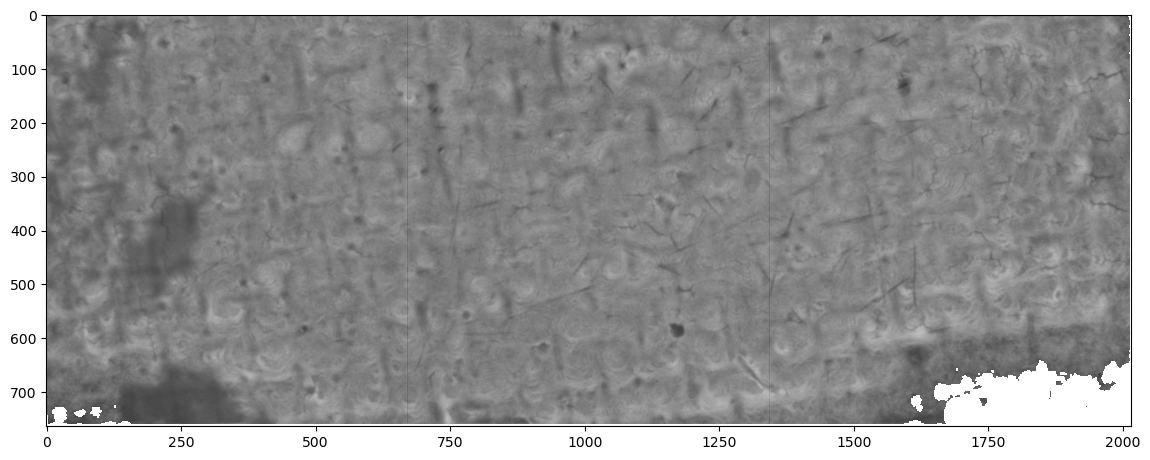

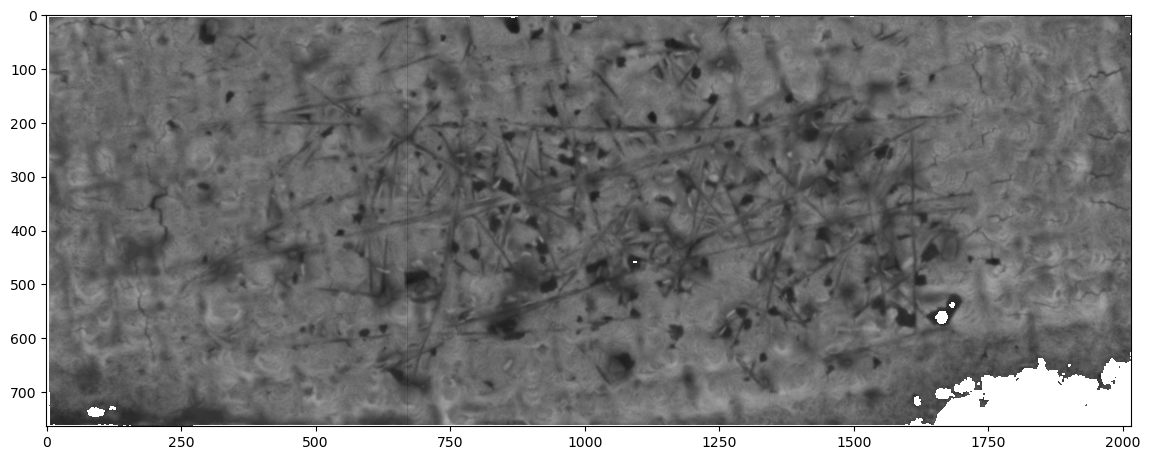

In [119]:
plt.figure(figsize=(14,7))
plt.imshow(np.nanmean(im_tom_0_ACL, axis=1), 'gray')

plt.figure(figsize=(14,7))
plt.imshow(np.nanmean(im_tom_1_ACL, axis=1), 'gray')

In [24]:
hist_tom_0 = np.histogram(np.nanmedian(im_tom_0_ACL, axis=1), bins = np.arange(0,1,0.025)*23000)
hist_tom_1 = np.histogram(np.nanmedian(im_tom_1_ACL, axis=1), bins = np.arange(0,1,0.025)*23000)

/tmp/ipykernel_427497/1291141906.py:1: RuntimeWarning: All-NaN slice encountered
  hist_tom_0 = np.histogram(np.nanmedian(im_tom_0_ACL, axis=1), bins = np.arange(0,1,0.025)*23000)
/tmp/ipykernel_427497/1291141906.py:2: RuntimeWarning: All-NaN slice encountered
  hist_tom_1 = np.histogram(np.nanmedian(im_tom_1_ACL, axis=1), bins = np.arange(0,1,0.025)*23000)


Text(0, 0.5, 'counts')

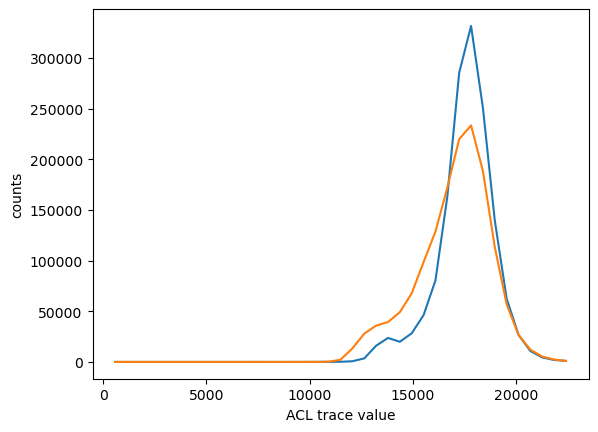

In [26]:
plt.plot(hist_tom_0[1][1:], hist_tom_0[0])
plt.plot(hist_tom_1[1][1:], hist_tom_1[0])
plt.xlabel('ACL trace value')
plt.ylabel('counts')

## labCT 0

In [81]:
path_CT_0_seg = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/ABCZ_CL_segmented/A_12_preop__ACL_segmented.tif'
path_CT_1_seg = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/ABCZ_CL_segmented/A_12_postop_2__ACL_segmented.tif'

In [104]:
im_ct_0 = np.transpose(skimage.io.imread(path_CT_0)[100:1100,50:550,:], (1,2,0))
im_ct_1 = np.transpose(skimage.io.imread(path_CT_1)[100:1100,50:550,:], (1,2,0))

im_ct_0_seg = np.transpose(skimage.io.imread(path_CT_0_seg), (1,2,0))<1
im_ct_1_seg = np.transpose(skimage.io.imread(path_CT_1_seg), (1,2,0))<1

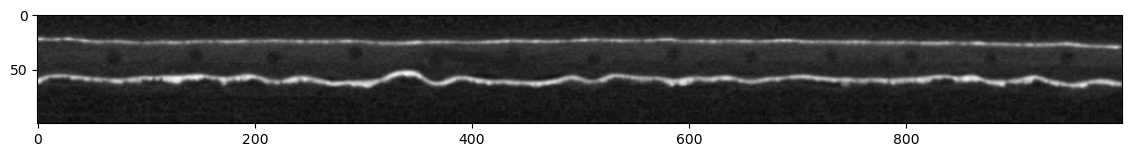

In [105]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_0[ct_slice,...], 'gray')

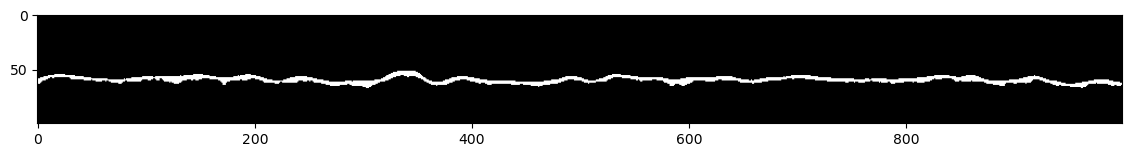

In [106]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_0_seg[ct_slice,...], 'gray')

In [89]:
im_ct_0_trace = pad_and_close3D(im_ct_0_seg, 30)

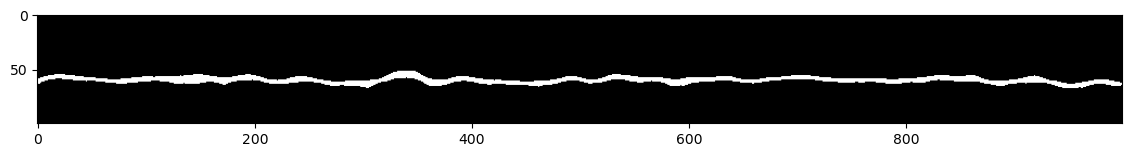

In [90]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_0_trace[ct_slice,...], 'gray')

In [107]:
im_ct_0_ACL = im_ct_0*1.0
im_ct_0_ACL[~im_ct_0_trace] = np.nan

## labCT 1

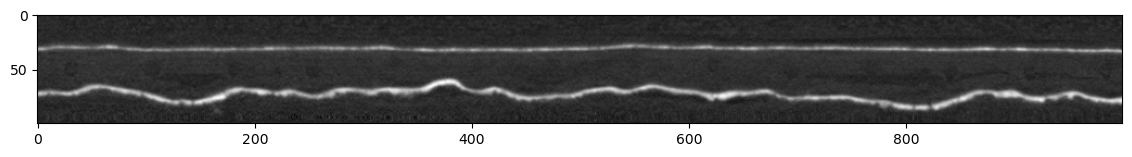

In [108]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_1[ct_slice,...], 'gray')

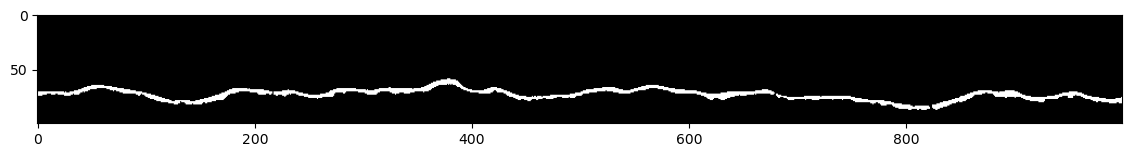

In [109]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_1_seg[ct_slice,...], 'gray')

In [110]:
im_ct_1_trace = pad_and_close3D(im_ct_1_seg, 30)

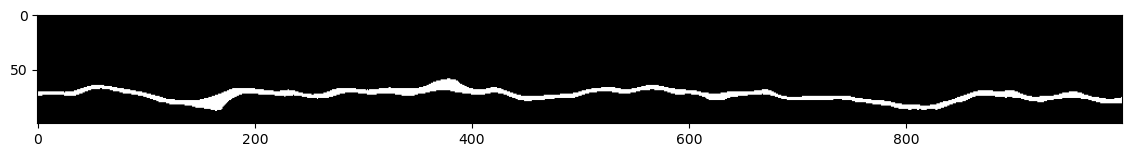

In [111]:
plt.figure(figsize=(14,7))
plt.imshow(im_ct_1_trace[ct_slice,...], 'gray')

In [112]:
im_ct_1_ACL = im_ct_1*1.0
im_ct_1_ACL[~im_ct_1_trace] = np.nan

/tmp/ipykernel_427497/1450076539.py:2: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(im_ct_0_ACL, axis=1), 'gray')
/tmp/ipykernel_427497/1450076539.py:5: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(im_ct_1_ACL, axis=1), 'gray')


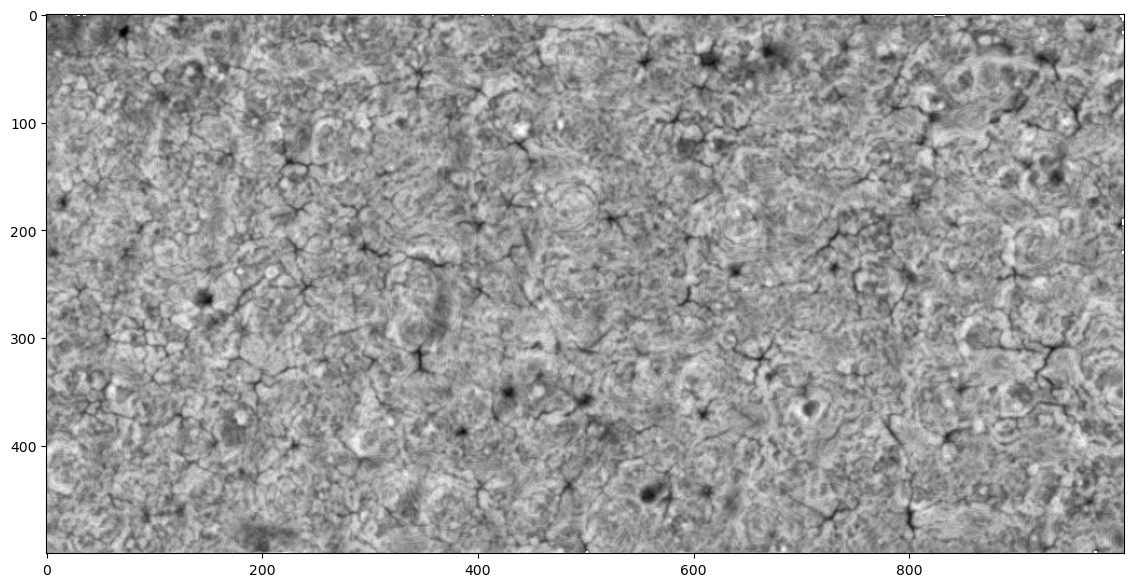

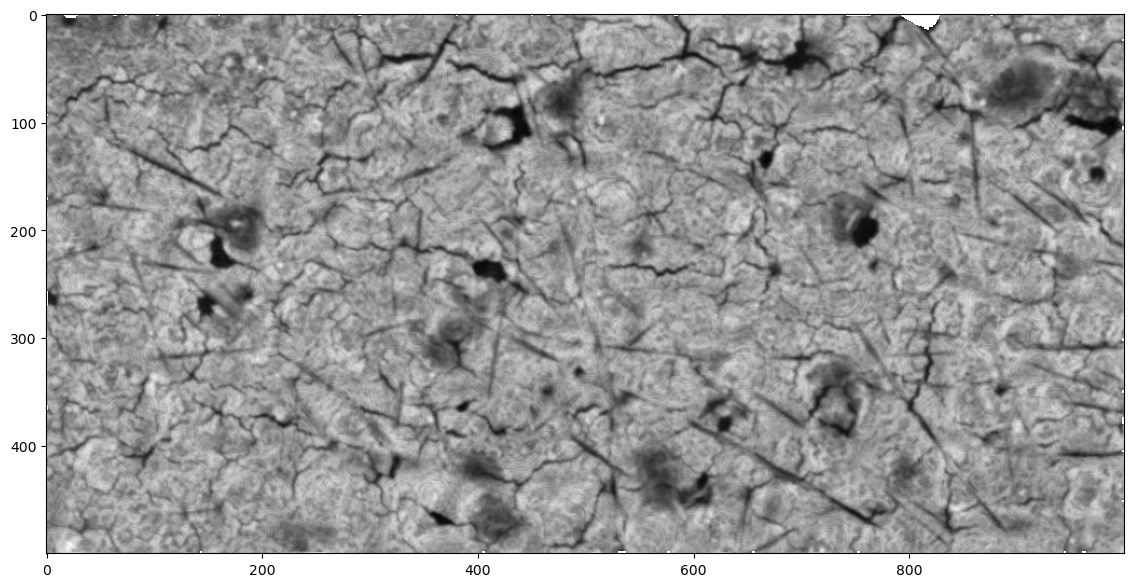

In [120]:
plt.figure(figsize=(14,7))
plt.imshow(np.nanmean(im_ct_0_ACL, axis=1), 'gray')

plt.figure(figsize=(14,7))
plt.imshow(np.nanmean(im_ct_1_ACL, axis=1), 'gray')

In [121]:
hist_ct_0 = np.histogram(np.nanmedian(im_ct_0_ACL, axis=1), bins = np.arange(0,1,0.025)*23000)
hist_ct_1 = np.histogram(np.nanmedian(im_ct_1_ACL, axis=1), bins = np.arange(0,1,0.025)*23000)

/tmp/ipykernel_427497/530771172.py:1: RuntimeWarning: All-NaN slice encountered
  hist_ct_0 = np.histogram(np.nanmedian(im_ct_0_ACL, axis=1), bins = np.arange(0,1,0.025)*23000)
/tmp/ipykernel_427497/530771172.py:2: RuntimeWarning: All-NaN slice encountered
  hist_ct_1 = np.histogram(np.nanmedian(im_ct_1_ACL, axis=1), bins = np.arange(0,1,0.025)*23000)


Text(0, 0.5, 'counts')

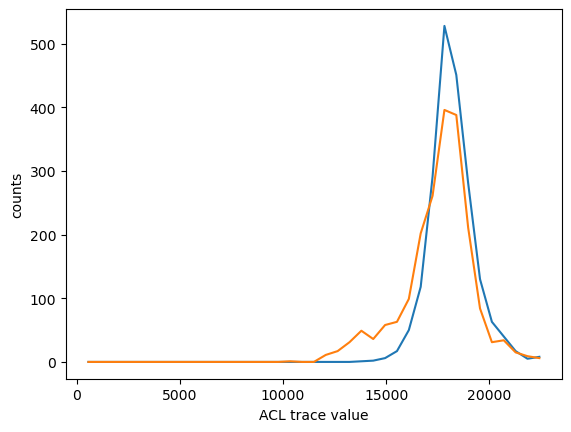

In [122]:
plt.plot(hist_ct_0[1][1:], hist_tom_0[0])
plt.plot(hist_ct_1[1][1:], hist_tom_1[0])
plt.xlabel('ACL trace value')
plt.ylabel('counts')

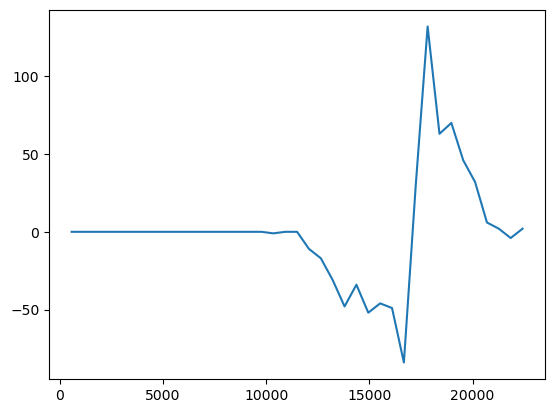

In [124]:
plt.plot(hist_ct_0[1][1:], hist_tom_1[0]- hist_tom_0[0])